### Load the data from the file and show: the first few rows, the output of the .describe() function, the number of rows and columns 

In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
file_name= 'exam_2021_01_27.csv'
random_state = 42
np.random.seed(random_state)
df=pd.read_csv(file_name)
df.head()

,5.1,3.5,a,Unnamed: 3,0
0,4.9,3.0,a,NaN,0
1,NaN,3.2,a,NaN,0
2,4.6,NaN,a,0.2,0
3,5.0,3.6,a,0.2,0
4,NaN,3.9,a,0.4,0


In [3]:
df.describe()

,5.1,3.5,Unnamed: 3,0
count,140.000000,139.000000,137.000000,149.000000
mean,5.903571,3.033094,1.290511,1.006711
std,0.820371,0.437448,0.733934,0.817847
min,4.300000,2.000000,0.100000,0.000000
25%,5.200000,2.800000,0.400000,0.000000
50%,5.850000,3.000000,1.400000,1.000000
75%,6.425000,3.300000,1.800000,2.000000
max,7.900000,4.400000,2.500000,2.000000


In [4]:
df.shape

(149, 5)

### Since the data contain nulls, eliminate the rows with nulls

In [5]:
dfclean=df.dropna()
dfclean.shape

(122, 5)

### Since one of the predicting attributes is ordinal, it must be converted into numeric, you can use the OrdinalEncoder

In [13]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
dfenc=oe.fit_transform(dfclean)
dfenc=pd.DataFrame(dfenc)
dfenc.head()

,0,1,2,3,4
0,5.0,15.0,0.0,1.0,0.0
1,5.0,13.0,0.0,1.0,0.0
2,8.0,16.0,0.0,1.0,0.0
3,3.0,13.0,0.0,1.0,0.0
4,0.0,9.0,0.0,0.0,0.0


### Split the data into train and test

In [17]:
from sklearn.model_selection import train_test_split

X = dfenc.drop(4, axis = 1)
y = dfenc[4]

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,train_size = 2/3, random_state = random_state)
print(f"We have {Xtrain.shape[0]} items in our training set")
print(f"We have {Xtest.shape[0]} items in our test set")

We have 81 items in our training set
We have 41 items in our test set


### Use two classification models of your choice (say: model 1 and model 2) execute the tasks below

### Model 1: find and show the best hyperparameter setting with cross validation on the training set, optimise for the best accuracy 

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Instantiate the DecisionTree Classifier
Model1 = DecisionTreeClassifier(random_state = random_state)

# Fit it to the training data
Model1.fit(Xtrain, ytrain)

# Create the range of parameters to try during cross-validation
dt_depths = range(1, Model1.get_depth() + 1)

scores = []

for par in dt_depths :
    model1 = DecisionTreeClassifier(criterion = 'entropy', max_depth = par, random_state = random_state)
    score = cross_val_score(model1, Xtrain, ytrain, scoring = 'accuracy', cv=5)
    scores.append(np.mean(score))
    #scores.append(sum(score) / len(score))
print (scores)



[np.float64(0.7772058823529411), np.float64(0.95), np.float64(0.95), np.float64(0.95)]


### Model 1: show the accuracy of classification and the confusion matrix on the test set For the confusion matrix use plot_confusion_matrix normalized in order to show for each class the precision (read carefully the documentation)

The accuracy on test set tuned with cross_validation with Model1 is 92.68% with depth 2
The accuracy score for the Decision Tree with the optimized hyperparameters was: 92.68%
The confusion matrix is:
Classification report: 
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         8
         1.0       0.89      0.94      0.91        17
         2.0       0.93      0.88      0.90        16

    accuracy                           0.93        41
   macro avg       0.94      0.94      0.94        41
weighted avg       0.93      0.93      0.93        41



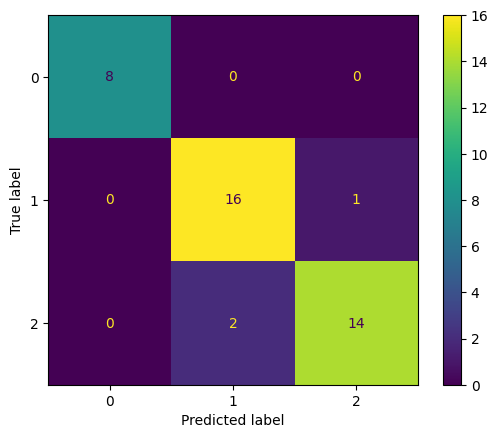

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
too_par = dt_depths[np.argmax(scores)]                          #prende l'indice il risultato migliore , best score
model1 = DecisionTreeClassifier(max_depth = too_par, criterion = 'entropy',random_state=random_state)
model1.fit(Xtest,ytest)

ytest_model = model1.predict(Xtest)
#Calculate the accuracy
accuracy = accuracy_score(ytest,ytest_model)*100
print("The accuracy on test set tuned with cross_validation with Model1 is {:.2f}% with depth {}".format(accuracy,too_par))
# Accuracy score
dt_accuracy = accuracy_score(ytest, ytest_model) * 100
print(f"The accuracy score for the Decision Tree with the optimized hyperparameters was: {dt_accuracy:.2f}%")

# Confusion matrix
print("The confusion matrix is:")
cm_DT = confusion_matrix(ytest,ytest_model)
CMD = ConfusionMatrixDisplay(cm_DT)
CMD.plot()

# Classification Report
print("Classification report: ")
print(classification_report(ytest, ytest_model))

### Model 2: find and show the best hyperparameter setting with cross validation on the training set, optimise for the best accuracy 

In [24]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the KNN Classifier
model2 = KNeighborsClassifier()

# Create the range of parameters to try during cross-validation
knn_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
scores2 = []
for i in knn_neighbors :
    model2 = KNeighborsClassifier(n_neighbors = i, metric = 'euclidean')
    score2 = cross_val_score(model2, Xtrain, ytrain, scoring = 'accuracy', cv=5)
    scores2.append(np.mean(score2))
print (scores2)

[np.float64(0.9375), np.float64(0.95), np.float64(0.9625), np.float64(0.95), np.float64(0.95), np.float64(0.9375), np.float64(0.9625), np.float64(0.95), np.float64(0.95), np.float64(0.9125)]


### . Model 2: show the accuracy of classification and the confusion matrix on the test set For the confusion matrix use plot_confusion_matrix normalized in order to show for each class the precision (read carefully the documentation)

The accuracy score for the Nearest Neighbors with the optimized hyperparameters was: 92.68%
The confusion matrix is:
Classification report: 
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         8
         1.0       0.85      1.00      0.92        17
         2.0       1.00      0.81      0.90        16

    accuracy                           0.93        41
   macro avg       0.95      0.94      0.94        41
weighted avg       0.94      0.93      0.93        41



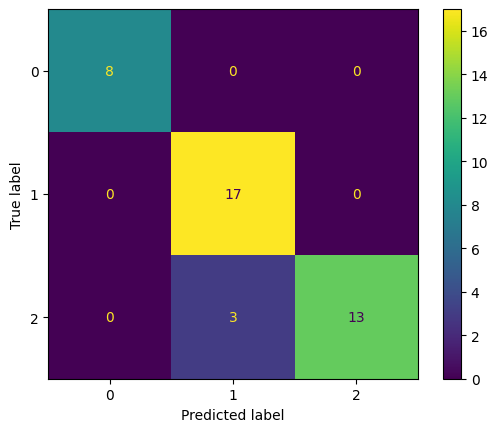

In [25]:
too_par = knn_neighbors[np.argmax(scores)]                          #prende l'indice il risultato migliore , best score
model2 = KNeighborsClassifier(n_neighbors = too_par, metric = 'euclidean')
model2.fit(Xtest,ytest)
ytest_model = model2.predict(Xtest)


# Accuracy score
knn_accuracy = accuracy_score(ytest, ytest_model) * 100
print(f"The accuracy score for the Nearest Neighbors with the optimized hyperparameters was: {knn_accuracy:.2f}%")

# Confusion matrix
print("The confusion matrix is:")
cm_KNN = confusion_matrix(ytest,ytest_model)
CMD = ConfusionMatrixDisplay(cm_KNN)
CMD.plot()

# Classification Report
print("Classification report: ")
print(classification_report(ytest, ytest_model))